In [ ]:
import matplotlib.pyplot as plt
from cube import Cube
from cube_nn import CubeValueNNConv, cube_to_tensor_one_hot_similar

In [5]:
import numpy as np

a = np.array([1,2,3])
print(a.shape)

print(a.min())

print(a.min() == 1)
print(f"a is of type {type(a)}")
print(f"a min: {a.min()}")

(3,)
1
True
a is of type <class 'numpy.ndarray'>
a min: 1


In [2]:
network = CubeValueNNConv()

In [3]:
cube = Cube()
cube.scramble(10)

tensor = cube_to_tensor_one_hot_similar(cube)
value = network(tensor)

In [ ]:
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from cube import Cube
from tqdm import tqdm


class TrainingDataset(Dataset):
    """A dataset for training the neural network."""

    def __init__(self, n_scrambles: int = 100, n_moves: int = 5):
        """
        Initializes the TrainingDataset.

        Args:
            n_scrambles (int): Number of scrambles to generate.
            n_moves (int): Number of moves in each scramble.
        """
        super(TrainingDataset, self).__init__()
        self._data = []

        for _ in tqdm(range(n_scrambles), desc="Generating scrambles"):
            cube = Cube()
            moves = cube.scramble(n_moves)

            cube = Cube()
            for i, move in enumerate(moves):
                cube.move(move)
                self._data.append((cube_to_tensor_one_hot_similar(cube), i))

    def __len__(self):
        return len(self._data)
    
    def __getitem__(self, idx):
        return self._data[idx]


dataset = TrainingDataset(n_scrambles=1000, n_moves=5)
dataloader = DataLoader(dataset, batch_size=20, shuffle=True)

criterion = nn.MSELoss()
optimizer = optim.Adam(network.parameters(), lr=0.001)
n_epochs = 10
losses = []
for epoch in range(n_epochs):
    running_loss = 0.0
    for inputs, targets in tqdm(dataloader, desc=f"Epoch {epoch+1}/{n_epochs}"):
        optimizer.zero_grad()
        outputs = network(inputs)
        loss = criterion(outputs.squeeze(), targets.float())
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(dataloader)
    losses.append(epoch_loss)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")




In [ ]:
from solvers import nn_value_function
from solvers import DepthValueSolver

nn_solver = DepthValueSolver(value_function=nn_value_function(network, cube_to_tensor_one_hot_similar), max_depth=2)

cube = Cube()
cube.scramble(15)
print("NN estimated value:", network(cube_to_tensor_one_hot_similar(cube)).item())
solution = nn_solver(cube)
print("Solution:", solution)

QSocketNotifier: Can only be used with threads started with QThread


Loaded single optimal value dataset from datasets/single_optimal/single_0.pt.


100%|██████████| 5000/5000 [00:59<00:00, 83.98it/s]


Loaded single optimal value dataset from datasets/single_optimal/single_1.pt.


100%|██████████| 5000/5000 [01:02<00:00, 79.55it/s]


...

Epoch 8, Train Loss: 1.5531, Val Loss: 3.3411


Epoch 9/10 - Validation: 100%|██████████| 800/800 [00:01<00:00, 400.69it/s]


Epoch 9, Train Loss: 1.3713, Val Loss: 3.4989


Epoch 10/10 - Validation: 100%|██████████| 800/800 [00:01<00:00, 410.30it/s]

Epoch 10, Train Loss: 1.2262, Val Loss: 3.5421


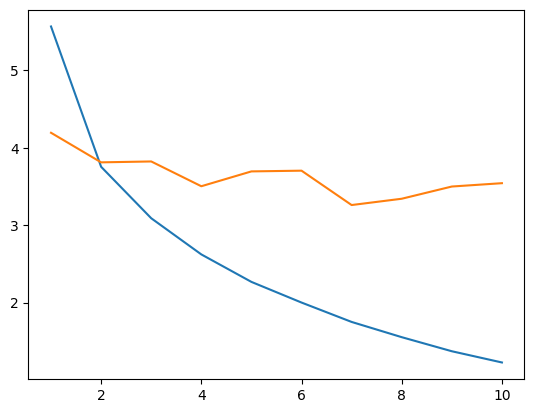

In [ ]:
import torch
import matplotlib.pyplot as plt
from cube_datasets import BalancedDataset
from cube_nn import CubeValueNNConv, cube_to_tensor_one_hot_similar
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from cube import Cube
from tqdm import tqdm

%matplotlib inline
    
dataset = BalancedDataset(n_moves_max=15, n_cubes_per_dataset=5000, seed=42)
    
# split into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_dataloader = DataLoader(train_dataset, batch_size=20, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=20, shuffle=False)
network = CubeValueNNConv()
criterion = nn.MSELoss()
optimizer = optim.Adam(network.parameters(), lr=0.001)
n_epochs = 10
train_losses = []
val_losses = []

network.eval()
running_val_loss = 0.0
with torch.no_grad():
    for inputs, targets in tqdm(val_dataloader, desc=f"Initial Validation"):
        outputs = network(inputs)
        loss = criterion(outputs.squeeze(), targets.float())
        running_val_loss += loss.item()
epoch_val_loss = running_val_loss / len(val_dataloader)
val_losses.append(epoch_val_loss)
print(f"Initial Val Loss: {epoch_val_loss:.4f}")

for epoch in range(n_epochs):
    network.train()
    running_loss = 0.0
    for inputs, targets in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{n_epochs} - Training"):
        optimizer.zero_grad()
        outputs = network(inputs)
        loss = criterion(outputs.squeeze(), targets.float())
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_dataloader)
    train_losses.append(epoch_train_loss)

    network.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{n_epochs} - Validation"):
            outputs = network(inputs)
            loss = criterion(outputs.squeeze(), targets.float())
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_dataloader)
    val_losses.append(epoch_val_loss)
    print(f"Epoch {epoch+1}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

plt.plot(range(1, n_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, n_epochs + 1), val_losses[1:], label='Validation Loss')

In [1]:
from cube_datasets import get_single_optimal_value_dataset, get_single_upper_bound_value_dataset

single_optimal_dataset = get_single_optimal_value_dataset(5)
single_upper_bound_dataset = get_single_upper_bound_value_dataset(8)

QSocketNotifier: Can only be used with threads started with QThread


Loaded single optimal value dataset from datasets/single_optimal/single_5.pt.
Single upper bound value dataset not found at datasets/single_upper_bound/single_upper_bound_8_1000.pt, generating it...


Generating cubes: 100%|██████████| 1000/1000 [00:00<00:00, 3522.65it/s]

Saved single upper bound value dataset to datasets/single_upper_bound/single_upper_bound_8_1000.pt.


In [1]:
from cube_datasets import BalancedDataset
from cube_datasets import BalancedDataset
from cube_nn import CubeValueNNConv
from torch import nn, optim
from torch.utils.data import DataLoader
from tqdm import tqdm

network = CubeValueNNConv()

# Learning
optimizer = optim.Adam(network.parameters(), lr=0.001)
criterion = nn.MSELoss()

def training_loop(network, dataset, n_epochs=10, batch_size=20):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    for epoch in tqdm(range(n_epochs), desc="Training Loop"):
        for inputs, targets in dataloader:
            optimizer.zero_grad()
            outputs = network(inputs)
            loss = criterion(outputs.squeeze(), targets.float())
            loss.backward()
            optimizer.step()


# step 1: learn on balanced dataset
# balanced_dataset = BalancedDataset.load(n_moves_max=15, n_cubes_per_dataset=100, seed=42)
balanced_dataset = BalancedDataset.create_new(n_moves_max=15, n_cubes_per_dataset=5000, seed=42)
training_loop(network, balanced_dataset, n_epochs=10, batch_size=50)

# step 2: iteratively create a new balanced dataset based on the cubes that the network overestimates
n_iterations = 5

for iteration in range(n_iterations):
    overestimated_dataset = BalancedDataset.create_from_overestimations(network, n_moves_max=15, n_cubes_per_dataset=1000)
    from_neighbors_dataset = BalancedDataset.create_from_neighbors(network, n_moves_max=15, n_cubes_per_dataset=1000)
    training_loop(network, overestimated_dataset, n_epochs=10, batch_size=50)
    training_loop(network, from_neighbors_dataset, n_epochs=10, batch_size=50)
    print(f"Iteration {iteration+1}/{n_iterations} completed.")


QSocketNotifier: Can only be used with threads started with QThread


Single upper bound value dataset not found at datasets/single_upper_bound/single_upper_bound_5_5000_42.pt, generating it...


Generating cubes: 100%|██████████| 5000/5000 [00:01<00:00, 4622.53it/s]


Saved single upper bound value dataset to datasets/single_upper_bound/single_upper_bound_5_5000_42.pt.


Training Loop: 100%|██████████| 10/10 [00:54<00:00,  5.43s/it]


...

Iteration 3/5 completed.


Training Loop: 100%|██████████| 10/10 [00:19<00:00,  1.99s/it]


Iteration 4/5 completed.


Training Loop: 100%|██████████| 10/10 [00:20<00:00,  2.01s/it]

Iteration 5/5 completed.


In [3]:
from solvers import nn_value_function, AStarSolver
from cube_nn import cube_to_tensor_one_hot_similar
from cube import Cube


nn_solver = AStarSolver(value_function=nn_value_function(network, cube_to_tensor_one_hot_similar), max_queue_size=10000)

cube = Cube()
scramble = cube.scramble(10)

print("NN estimated value:", network(cube_to_tensor_one_hot_similar(cube)).item())
print("Scramble moves:", scramble)
solution = nn_solver(cube)
print("Solution:", solution)

NN estimated value: 8.189996719360352
Scramble moves: [L2, D', F, R', F, B', U', B', U2, R2]
Solution: None


In [1]:
from cube_datasets import BalancedDataset

dataset = BalancedDataset(n_moves_max=15, n_cubes_per_dataset=100, seed=42)

QSocketNotifier: Can only be used with threads started with QThread


In [2]:
from cube_datasets import BalancedDataset

dataset = BalancedDataset.load(n_moves_max=15, n_cubes_per_dataset=100, seed=42)

QSocketNotifier: Can only be used with threads started with QThread
